In [3]:
from classy import Class
import numpy as np
import matplotlib.pyplot as plt

In this program, we want to calculate how, in a universe whose dark matter composition is comprised only of WDM, varying the WDM mass affects the transfer function. We will fix $\Omega_{DM}h^2 = \Omega_{WDM}h^2 \approx 0.12$. 

We can relate $\Omega_{WDM}h^2, T_{WDM},$ and $m_{WDM}$ in one equation once given a phase space distribution and assuming the WDM is non-relativistic now. From equation (A4) in the the paper, assuming a Fermi-Dirac phase space distribution, and using the chosen $\Omega_{WDM}$ (see your notes for derivation):

$$ T_{WDM} \approx \frac{0.16}{(m_{WDM})^\frac 1 3} $$

These parameters are then fed to CLASS to calculate the corresponding transfer function.

In [43]:
# Initializing
omega_dm = 0.1201075

m1 = 1
m2 = 5
m3 = 10

# takes m in keV
def T_wdm(m): 
    return 0.16 / np.cbrt(m)



In [44]:
# Universe 1
params1 = {
    "output": "mTk",

    "omega_cdm": 0.0,
    "omega_ncdm": omega_dm,
    "N_ncdm": 1,
    "m_ncdm": m1,
    "T_ncdm": T_wdm(m1),
    "deg_ncdm": 2,
}

# Universe 2
params2 = {
    "output": "mTk",

    "omega_cdm": 0.0,
    "omega_ncdm": omega_dm,
    "N_ncdm": 1,
    "m_ncdm": m2,
    "T_ncdm": T_wdm(m2),
    "deg_ncdm": 2,
}

# Universe 3
params3 = {
    "output": "mTk",

    "omega_cdm": 0.0,
    "omega_ncdm": omega_dm,
    "N_ncdm": 1,
    "m_ncdm": m3,
    "T_ncdm": T_wdm(m3),
    "deg_ncdm": 2,
}

# compute cosmologies
cosmo1 = Class()
cosmo1.set(params1)
cosmo1.compute()

cosmo2 = Class()
cosmo2.set(params2)
cosmo2.compute()

cosmo3 = Class()
cosmo3.set(params3)
cosmo3.compute()

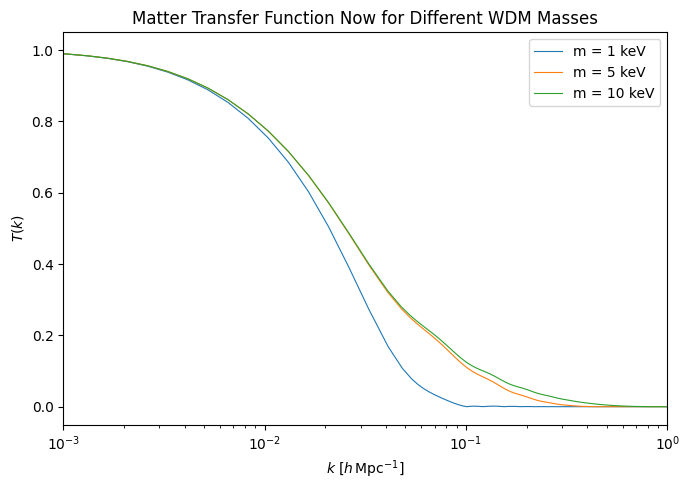

In [47]:
# get transfer function data
transfer_data1 = cosmo1.get_transfer(z=0)
ks1 = transfer_data1["k (h/Mpc)"]
d_m1 = transfer_data1['d_m']

transfer_data2 = cosmo2.get_transfer(z=0)
ks2 = transfer_data2["k (h/Mpc)"]
d_m2 = transfer_data2['d_m']

transfer_data3 = cosmo3.get_transfer(z=0)
ks3 = transfer_data3["k (h/Mpc)"]
d_m3 = transfer_data3['d_m']


# normalizing transfer function properly
transfer1 = np.abs(d_m1) / ks1**2
transfer1 /= transfer1[0]

transfer2 = np.abs(d_m2) / ks2**2
transfer2 /= transfer2[0]

transfer3 = np.abs(d_m3) / ks3**2
transfer3 /= transfer3[0]

# Plot
plt.figure(figsize=(7, 5))
plt.xscale("log")
plt.xlim(1e-3, 1)
plt.plot(ks1, transfer1, lw=0.8, label="m = 1 keV")
plt.plot(ks2, transfer2, lw=0.8, label="m = 5 keV")
plt.plot(ks3, transfer3, lw=0.8, label="m = 10 keV")
plt.xlabel(r"$k \ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$T(k)$")
plt.title("Matter Transfer Function Now for Different WDM Masses")
plt.legend()
plt.tight_layout()
plt.show()

A lighter WDM particle has a longer free streaming length, and suppresses larger scales. Hence the fall-off of the blue m = 1keV line begins at lower k than the other WDM mass cases (lower frequency -> greater lengths). 

Here, we are fixing the dark matter energy density, so, as we increase the WDM mass, the number density decreases in order to compensate. This likely accounts for the fact that the heavier WDM particle isn't causing the most structure suppression at small scales. 